In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Project 1: Ringing Effect

read the image first

Shape: (800, 800)
Data type: float64
MAX value: 255.0
MIN value: 0.0


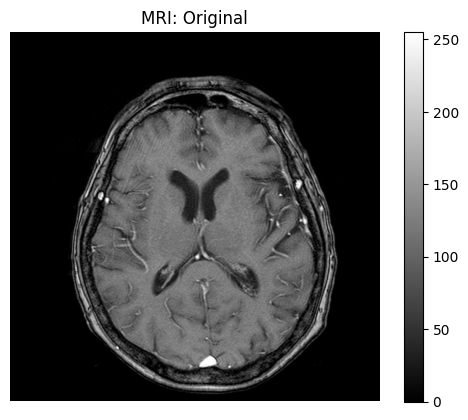

In [2]:
# open the iamge lab3.npy
img = np.load('./input/lab3.npy')

# show the infromation of the image
print("Shape:", img.shape)
print("Data type:", img.dtype)
print("MAX value:", img.max())
print("MIN value:", img.min())

# show the image
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.title("MRI: Original")
plt.axis('off')
plt.show()

### Lowpass Filter: Ideal Low-pass

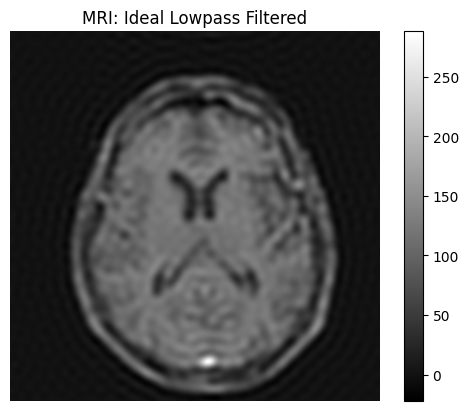

In [3]:
""" Get H: H = 1, when r <= D_0 """
# get the shape of the image
rows, cols = img.shape
# get the axises of the image
u = np.arange(rows) - rows // 2
v = np.arange(cols) - cols // 2
# get the meshgrid of the axises
U, V = np.meshgrid(u, v)
D = np.sqrt(U**2 + V**2)

# set D_0
D_0 = 30

# get Ideal Lowpass Filter: H
H_ideal = (D <= D_0).astype(float)

""" Apply the filter: G = H * F """
# transform the iamge to frequency domain
F = np.fft.fftshift(np.fft.fft2(img))
# apply the filter: multiply pixel by pixel
G_ideal = H_ideal * F
g_ideal = np.fft.ifft2(np.fft.ifftshift(G_ideal)).real

# show the image
plt.imshow(g_ideal, cmap='gray')
plt.colorbar()
plt.title("MRI: Ideal Lowpass Filtered")
plt.axis('off')
plt.show()


实现滤波部分操作比较统一，只需要修改应用的滤波器即可，因此考虑将滤波操作封装成函数。

In [4]:
# function: apply the filter
def applyFrequencyFilter(img, H):
    F = np.fft.fftshift(np.fft.fft2(img))
    G = H * F
    g = np.fft.ifft2(np.fft.ifftshift(G)).real
    return g

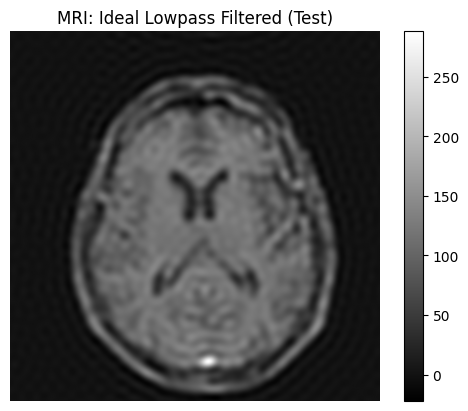

In [5]:
# test: ideal lowpass filter
g_ideal_test = applyFrequencyFilter(img, H_ideal)
# show the image
plt.imshow(g_ideal_test, cmap='gray')
plt.colorbar()
plt.title("MRI: Ideal Lowpass Filtered (Test)")
plt.axis('off')
plt.show()

测试通过，接下来只需要写不同的滤波器即可。

### Lowpass Filter: Ideal Low-pass, Butterworth(n = 6), Gaussian

AttributeError: 'Axes' object has no attribute 'colorbar'

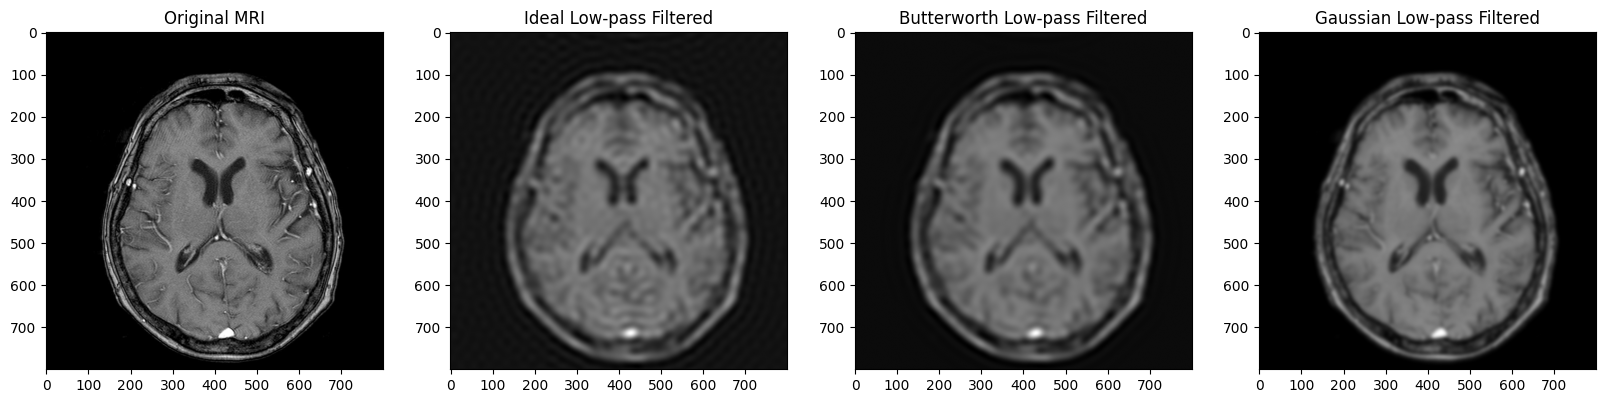

In [6]:
""" Low-pass Filters """
# 1. Ideal Low-pass Filter: H_ideal
H_ideal = (D <= D_0).astype(float)
# 2. Butterworth Low-pass Filter: H_butterworth
n = 6
H_butterworth = 1 / (1 + (D / D_0)**(2 * n))
# 3. Gaussian Low-pass Filter: H_gaussian
H_gaussian = np.exp(-(D**2) / (2 * (D_0**2)))


""" Apply the Filters """
# 1. Ideal Low-pass Filter
g_ideal = applyFrequencyFilter(img, H_ideal)
# 2. Butterworth Low-pass Filter
g_butterworth = applyFrequencyFilter(img, H_butterworth)
# 3. Gaussian Low-pass Filter
g_gaussian = applyFrequencyFilter(img, H_gaussian)


""" Show the Images """
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original MRI')
ax[1].imshow(g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered')
ax[2].imshow(g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered')
ax[3].imshow(g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered')
for a in ax:
    a.colorbar()
    a.axis('off')
plt.show()

报错原因：a 是一个 Axes 类型变量，不能实现添加 colorbar 的操作。去掉即可。

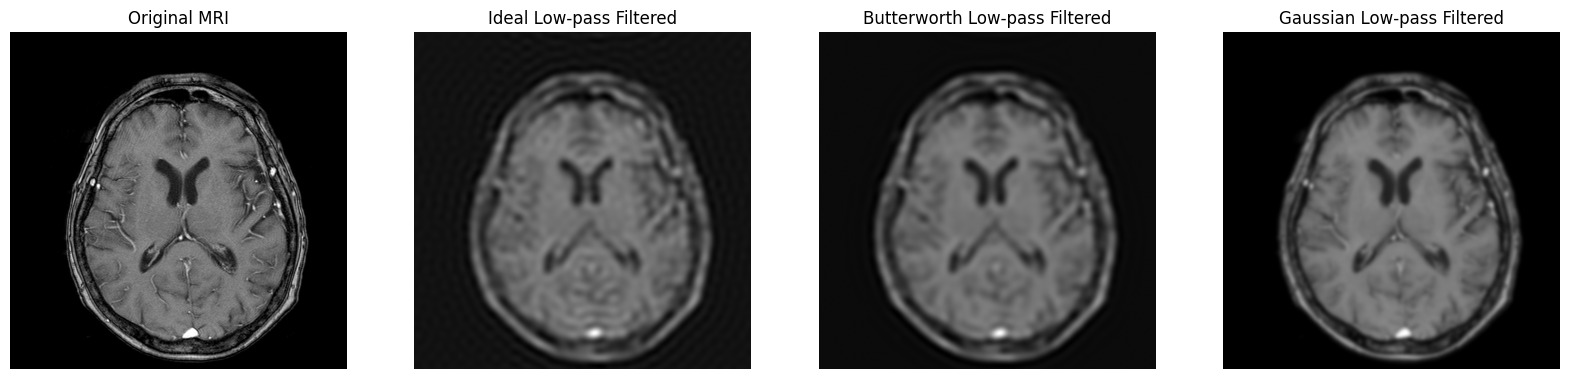

In [7]:
""" Low-pass Filters """
# 1. Ideal Low-pass Filter: H_ideal
H_ideal = (D <= D_0).astype(float)
# 2. Butterworth Low-pass Filter: H_butterworth
n = 6
H_butterworth = 1 / (1 + (D / D_0)**(2 * n))
# 3. Gaussian Low-pass Filter: H_gaussian
H_gaussian = np.exp(-(D**2) / (2 * (D_0**2)))


""" Apply the Filters """
# 1. Ideal Low-pass Filter
g_ideal = applyFrequencyFilter(img, H_ideal)
# 2. Butterworth Low-pass Filter
g_butterworth = applyFrequencyFilter(img, H_butterworth)
# 3. Gaussian Low-pass Filter
g_gaussian = applyFrequencyFilter(img, H_gaussian)


""" Show the Images """
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original MRI')
ax[1].imshow(g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered')
ax[2].imshow(g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered')
ax[3].imshow(g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered')
for a in ax:
    a.axis('off')
plt.show()

### Point out the ringing effect and explain the cause

理想低通滤波器在图像边缘会产生水波纹状的“振铃效应”，也就是 Ringing Effect。

这是因为：频率域中的非常突兀的阶跃截断在空间域对应的脉冲响应是 Sinc 函数，Sinc 函数具有无限延伸的旁瓣。除了高斯滤波器外，其他滤波器不可避免在空间上存在部分旁瓣能量，因此都有 Ringing Effect。高斯滤波器的傅里叶变换结果还是高斯函数，因此没有旁瓣，在图像上就是变模糊了，但是没有所谓的 Ringing Effect。

可以对一个白点进行滤波，可以清晰观察以上现象。

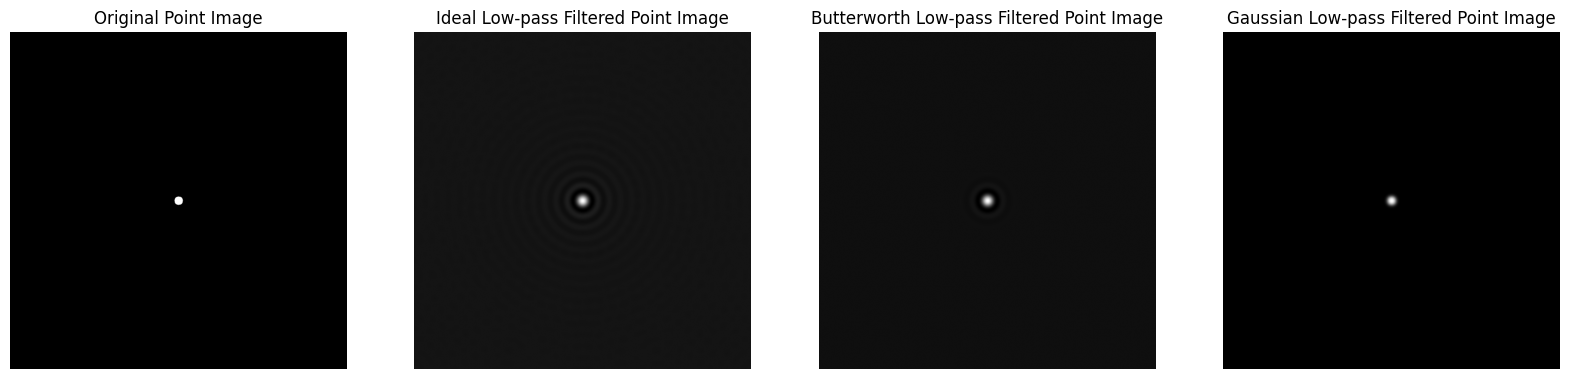

In [8]:
# white point image
point_img = (D <= 10).astype(float)


# Apply the Filters
# 1. Ideal Low-pass Filter
point_g_ideal = applyFrequencyFilter(point_img, H_ideal)
# 2. Butterworth Low-pass Filter
point_g_butterworth = applyFrequencyFilter(point_img, H_butterworth)
# 3. Gaussian Low-pass Filter
point_g_gaussian = applyFrequencyFilter(point_img, H_gaussian)

# Show the Images
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(point_img, cmap='gray')
ax[0].set_title('Original Point Image')
ax[1].imshow(point_g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered Point Image')
ax[2].imshow(point_g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered Point Image')
ax[3].imshow(point_g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered Point Image')
for a in ax:
    a.axis('off')
plt.show()

## Project 2: Identical Filter

### Implement a spatial filter

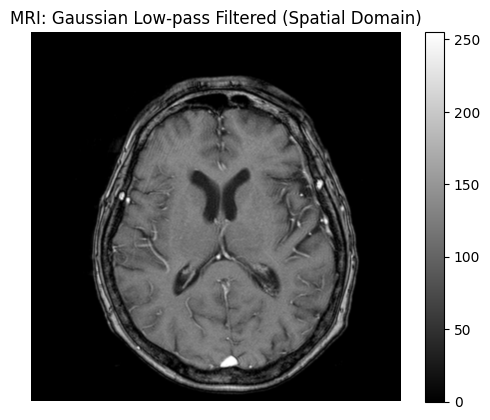

In [9]:
"""  Low pass Gaussian Filter: sigma = 1 """
# set sigma
sigma = 1
# caculate the kernel size: 3 sigma rule
k_size = 6 * sigma + 1

# create the Gaussian kernel
kernel_axises = np.arange(-k_size // 2 + 1, k_size // 2 + 1)
X, Y = np.meshgrid(kernel_axises, kernel_axises)
kernel_gaussian = np.exp(-(X**2 + Y**2) / (2 * (sigma**2)))

# normalize the kernel
kernel_gaussian /= kernel_gaussian.sum()

""" Apply the Gaussian Filter in spatial domain """
# padding the image
kernel_padding = k_size // 2
padded_img = np.pad(img, kernel_padding, mode='edge')
result_gaussian_spatial = np.zeros_like(img, dtype=float)

# convolution
for i in range(k_size):
    for j in range(k_size):
        result_gaussian_spatial += kernel_gaussian[i, j] * padded_img[i:i + img.shape[0], j:j + img.shape[1]]

# show the iamge
plt.imshow(result_gaussian_spatial, cmap='gray')
plt.colorbar()
plt.title("MRI: Gaussian Low-pass Filtered (Spatial Domain)")
plt.axis('off')
plt.show()


看不出啥效果，但是因为 sigma = 1，本来应该也没有很大的模糊。

生成高斯卷积核和卷积部分先封装一下。

In [10]:
# generate Gaussian Kernal
def generateGaussianKernal(sigma):
    # calculate kernel size
    kernel_size = 6 * sigma + 1
    # create the Gaussian kernel
    kernel_axises = np.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1)
    X, Y = np.meshgrid(kernel_axises, kernel_axises)
    kernel_gaussian = np.exp(-(X**2 + Y**2) / (2 * (sigma**2)))
    # normalize the kernel
    return kernel_gaussian / kernel_gaussian.sum()

# calculate 2d convolution
def numpy_conv2d(image, kernel):
    # padding the image
    kernel_height, kernel_width = kernel.shape
    padding_height, padding_width = kernel_height // 2, kernel_width // 2
    padded_img = np.pad(image, ((padding_height, padding_height), (padding_width, padding_width)), mode='edge')

    # calculate the result
    result = np.zeros_like(image, dtype=float)
    for i in range(kernel_height):
        for j in range(kernel_width):
            result += kernel[i, j] * padded_img[i:i+image.shape[0], j:j+image.shape[1]]

    return result


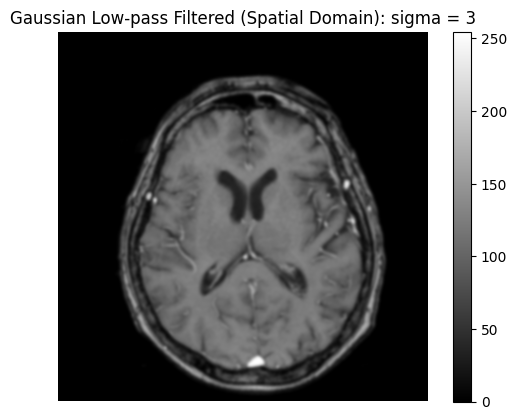

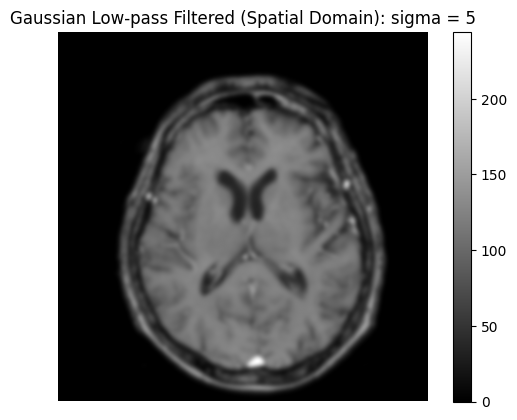

In [11]:
# test 
kernel_gaussian_3 = generateGaussianKernal(3)
img_spatial_lp_3 = numpy_conv2d(img, kernel_gaussian_3)
kernel_gaussian_5 = generateGaussianKernal(5)
img_spatial_lp_5 = numpy_conv2d(img, kernel_gaussian_5)

# show the image
plt.imshow(img_spatial_lp_3, cmap='gray')
plt.colorbar()
plt.title("Gaussian Low-pass Filtered (Spatial Domain): sigma = 3")
plt.axis('off')
plt.show()

plt.imshow(img_spatial_lp_5, cmap='gray')
plt.colorbar()
plt.title("Gaussian Low-pass Filtered (Spatial Domain): sigma = 5")
plt.axis('off')
plt.show()

从 sigma = 1 到 sigma = 5 的变化中，图像的模糊还是挺明显的。低通效果不错。高通就是原图减去低通。

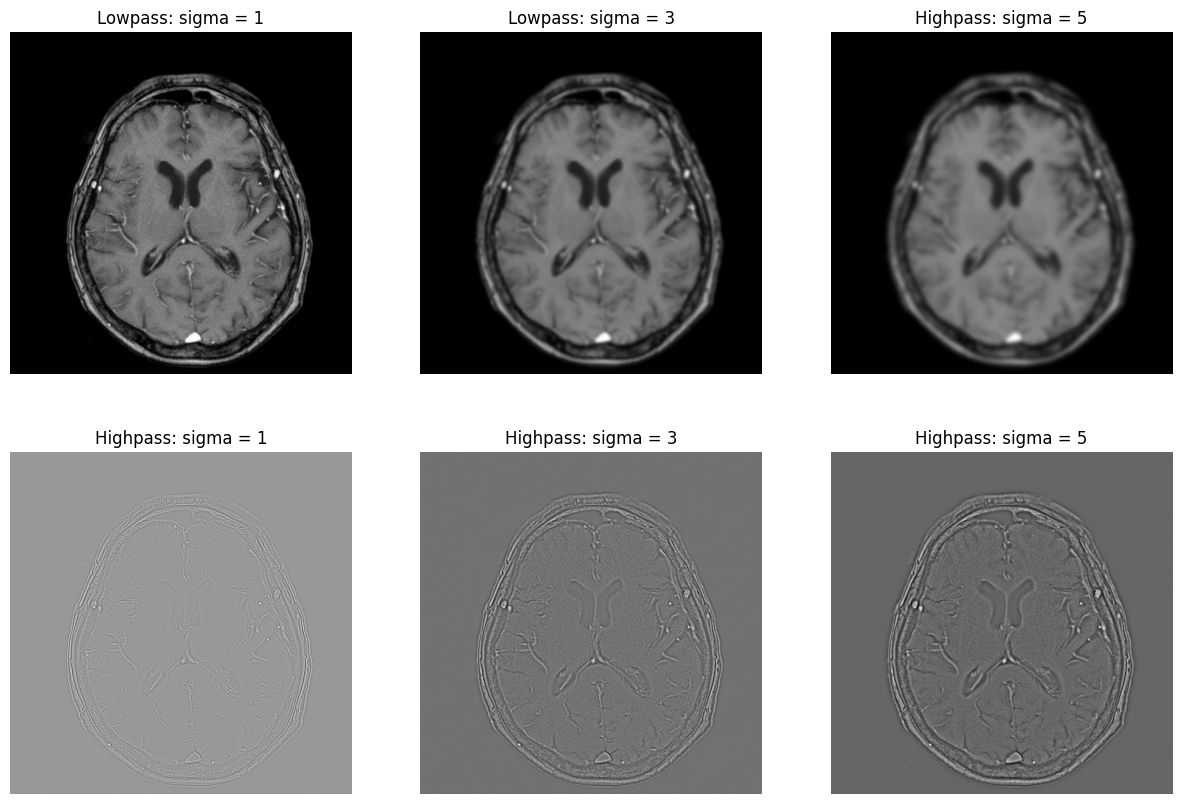

In [12]:
# lowpass filter
kernel_gaussian_1 = generateGaussianKernal(1)
img_spatial_lp_1 = numpy_conv2d(img, kernel_gaussian_1)
img_spatial_hp_1 = img - img_spatial_lp_1
kernel_gaussian_3 = generateGaussianKernal(3)
img_spatial_lp_3 = numpy_conv2d(img, kernel_gaussian_3)
img_spatial_hp_3 = img - img_spatial_lp_3
kernel_gaussian_5 = generateGaussianKernal(5)
img_spatial_lp_5 = numpy_conv2d(img, kernel_gaussian_5)
img_spatial_hp_5 = img - img_spatial_lp_5

# show the images
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(img_spatial_lp_1, cmap='gray')
ax[0, 0].set_title('Lowpass: sigma = 1')
ax[0, 1].imshow(img_spatial_lp_3, cmap='gray')
ax[0, 1].set_title('Lowpass: sigma = 3')
ax[0, 2].imshow(img_spatial_lp_5, cmap='gray')
ax[0, 2].set_title('Highpass: sigma = 5')
ax[1, 0].imshow(img_spatial_hp_1, cmap='gray')
ax[1, 0].set_title('Highpass: sigma = 1')
ax[1, 1].imshow(img_spatial_hp_3, cmap='gray')
ax[1, 1].set_title('Highpass: sigma = 3')
ax[1, 2].imshow(img_spatial_hp_5, cmap='gray')
ax[1, 2].set_title('Highpass: sigma = 5')
for a in ax.flatten():
    a.axis('off')
plt.show()


### Apply frequency filter

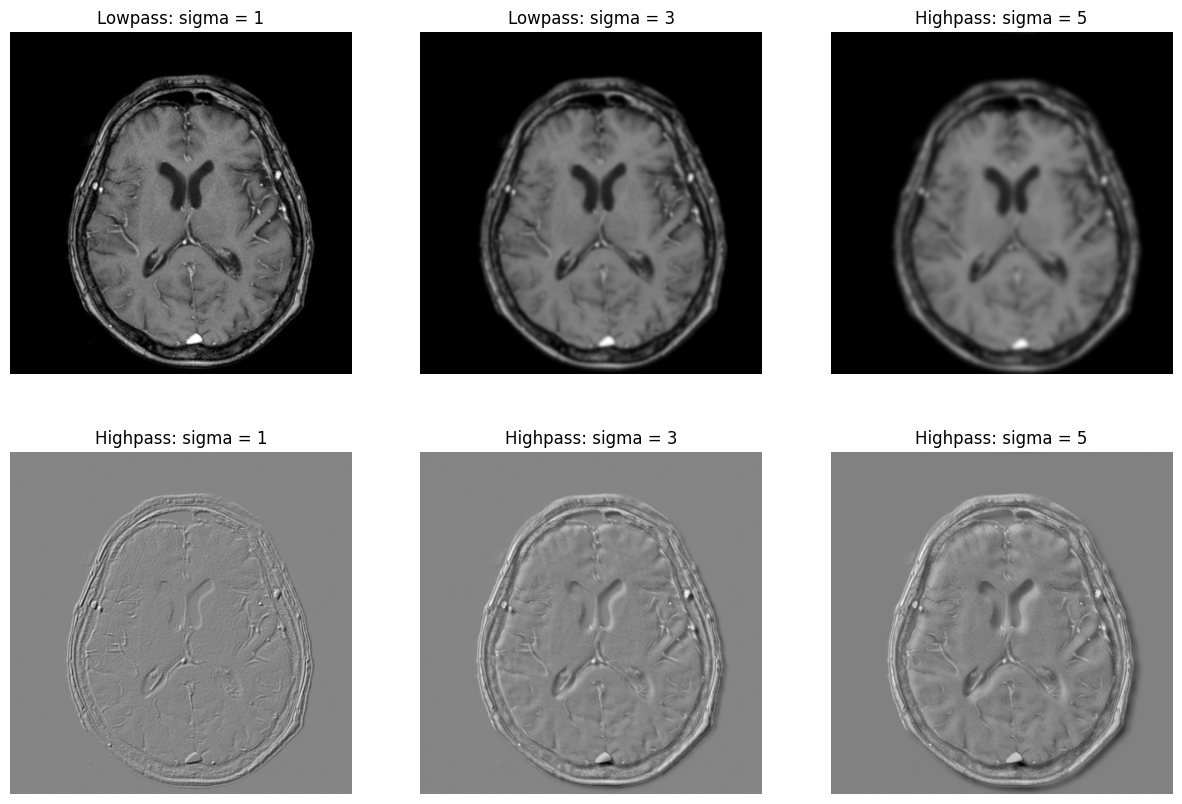

In [13]:
# perform Fourier Transform on image
F_img = np.fft.fftshift(np.fft.fft2(img))
# perform Fourier Transform on kernel
H_kernel_lp_1 = np.fft.fftshift(np.fft.fft2(kernel_gaussian_1, s=img.shape))
H_kernel_hp_1 = np.ones_like(H_kernel_lp_1) - H_kernel_lp_1
H_kernel_lp_3 = np.fft.fftshift(np.fft.fft2(kernel_gaussian_3, s=img.shape))
H_kernel_hp_3 = np.ones_like(H_kernel_lp_3) - H_kernel_lp_3
H_kernel_lp_5 = np.fft.fftshift(np.fft.fft2(kernel_gaussian_5, s=img.shape))
H_kernel_hp_5 = np.ones_like(H_kernel_lp_5) - H_kernel_lp_5

# apply frequency filter
img_frequency_lp_1 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_lp_1)).real
img_frequency_lp_3 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_lp_3)).real
img_frequency_lp_5 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_lp_5)).real
img_frequency_hp_1 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_hp_1)).real
img_frequency_hp_3 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_hp_3)).real
img_frequency_hp_5 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_hp_5)).real

# show the images
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(img_frequency_lp_1, cmap='gray')
ax[0, 0].set_title('Lowpass: sigma = 1')
ax[0, 1].imshow(img_frequency_lp_3, cmap='gray')
ax[0, 1].set_title('Lowpass: sigma = 3')
ax[0, 2].imshow(img_frequency_lp_5, cmap='gray')
ax[0, 2].set_title('Highpass: sigma = 5')
ax[1, 0].imshow(img_frequency_hp_1, cmap='gray')
ax[1, 0].set_title('Highpass: sigma = 1')
ax[1, 1].imshow(img_frequency_hp_3, cmap='gray')
ax[1, 1].set_title('Highpass: sigma = 3')
ax[1, 2].imshow(img_frequency_hp_5, cmap='gray')
ax[1, 2].set_title('Highpass: sigma = 5')
for a in ax.flatten():
    a.axis('off')
plt.show()

### Implement a Laplacian high pass filter

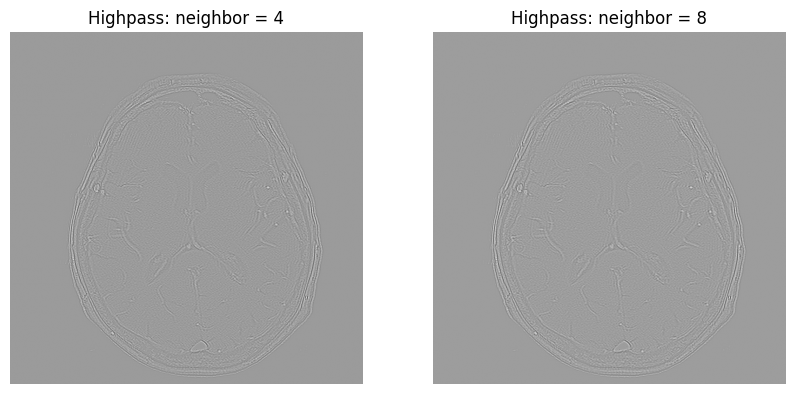

In [14]:
# Laplacian Highpass Filter
# neighbor: 4
laplacian_4 = np.array([[ 0, -1,  0], 
                        [-1,  4, -1], 
                        [ 0, -1,  0]], dtype=float)
# neighbor: 8
laplacian_8 = np.array([[-1, -1, -1], 
                        [-1,  8, -1], 
                        [-1, -1, -1]], dtype=float)

# Perform Highpass Filter on image
img_laplacian_4 = numpy_conv2d(img, laplacian_4)
img_laplacian_8 = numpy_conv2d(img, laplacian_8)

# show the result
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_laplacian_4, cmap='gray')
ax[0].set_title('Highpass: neighbor = 4')
ax[1].imshow(img_laplacian_8, cmap='gray')
ax[1].set_title('Highpass: neighbor = 8')
for a in ax:
    a.axis("off")
plt.show()

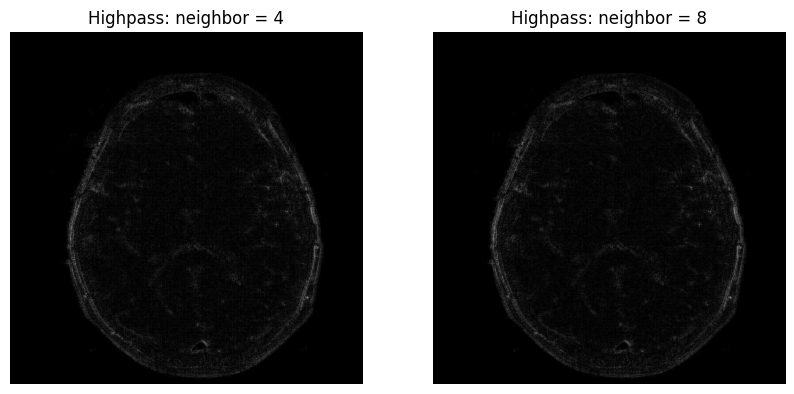

In [15]:
# show the result
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(np.abs(img_laplacian_4), cmap='gray')
ax[0].set_title('Highpass: neighbor = 4')
ax[1].imshow(np.abs(img_laplacian_8), cmap='gray')
ax[1].set_title('Highpass: neighbor = 8')
for a in ax:
    a.axis("off")
plt.show()

纵向对比一下

- 频率域 vs 空间域：空间域卷积理论上等价于频率域乘积。但从结果来看，两者的高通滤波后的图像差异还是挺大的。这一差异可以从数学上推导出来，主要来源于对高斯核的截断。因为要满足 $G = F \cdot H$，必须满足两矩阵的大小相同，那么高斯核的大小就不可能在频率域无限延伸，真正参与计算的滤波器是 $H_{\text{padded}} = H \cdot p_{u \le u_0, v \le v_0}$。在此基础上，就会导致通过高通滤波器的图像在空间域上，呈现一定的边缘平滑。

- 高斯高通 vs 拉普拉斯：拉普拉斯对高频极其敏感，边缘提取锐利但会严重放大噪声。高斯高通等价于先平滑再提取高频，过渡平滑，具有更好的抗噪性。

## Project 3: Notch Filter

看看图像先

Shape: (800, 800)
Data type: float64
MAX value: 255.0
MIN value: 0.0


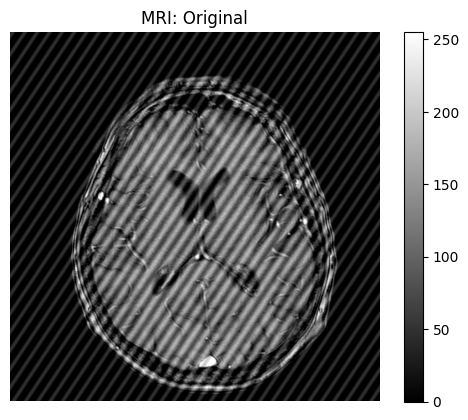

In [16]:
# open the iamge lab3.npy
img_noise = np.load('./input/lab3_noise.npy')

# show the infromation of the image
print("Shape:", img_noise.shape)
print("Data type:", img_noise.dtype)
print("MAX value:", img_noise.max())
print("MIN value:", img_noise.min())

# show the image
plt.imshow(img_noise, cmap='gray')
plt.colorbar()
plt.title("MRI: Original")
plt.axis('off')
plt.show()

看看频域

TypeError: Image data of dtype complex128 cannot be converted to float

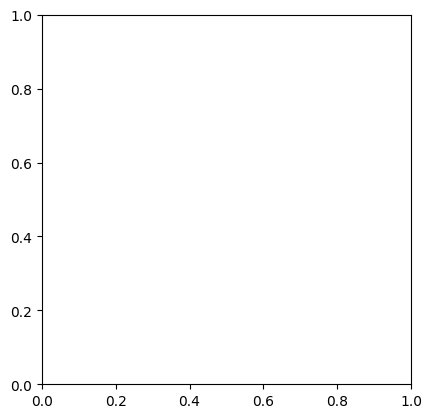

In [17]:
F_img_noise = np.fft.fftshift(np.fft.fft2(img_noise))

# show the image
plt.imshow(F_img_noise, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.axis('off')
plt.show()

复数无法显示，应该套一个 `abs()`。

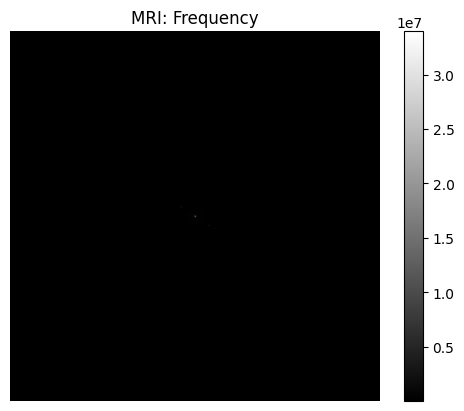

In [18]:
# show the image
plt.imshow(np.abs(F_img_noise), cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.axis('off')
plt.show()

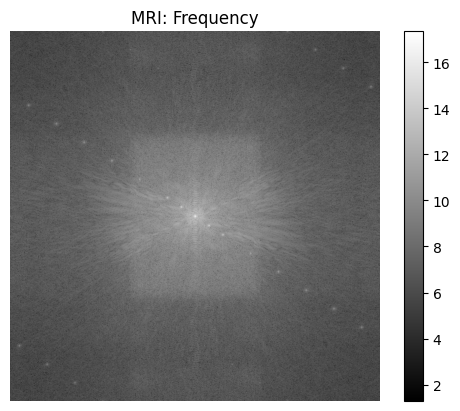

In [19]:
# show the image
plt.imshow(np.log(1 + np.abs(F_img_noise)), cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.axis('off')
plt.show()

要定位噪声的位置

In [20]:
import cv2

def drawCircle(img: np.ndarray, x: int, y: int, r: float, w: float):
    color = (255, 0, 0)
    img_rgb = np.stack([img, img, img], axis=-1)
    return cv2.circle(img_rgb, (x, y), r, color, w)

ModuleNotFoundError: No module named 'cv2'

报错原因：没有 install cv2 包

In [21]:
!uv add cv2

import cv2

def drawCircle(img: np.ndarray, x: int, y: int, r: float, w: float):
    color = (255, 0, 0)
    img_rgb = np.stack([img, img, img], axis=-1)
    return cv2.circle(img_rgb, (x, y), r, color, w)

⠸                                                                                 × No solution found when resolving dependencies for split (markers:
  │ python_full_version >= '3.14' and sys_platform == 'win32'):
  ╰─▶ Because there are no versions of cv2 and your project depends on cv2, we
      can conclude that your project's requirements are unsatisfiable.

      hint: While the active Python version is 3.13, the resolution failed for
      other Python versions supported by your project. Consider limiting your
      project's supported Python versions using `requires-python`.
  help: If you want to add the package regardless of the failed resolution,
        provide the `--frozen` flag to skip locking and syncing.


ModuleNotFoundError: No module named 'cv2'

错误原因：包的名字搞错了。。。

In [22]:
!uv add opencv-python

import cv2

def drawCircle(img: np.ndarray, x: int, y: int, r: int, w: int):
    color = (1.0, 0, 0)
    img_rgb = np.stack([img, img, img], axis=-1)
    return cv2.circle(img_rgb, (x, y), r, color, w)

Resolved 121 packages in 697ms                                       
░░░░░░░░░░░░░░░░░░░░ [0/1] Installing wheels...                                      ░░░░░░░░░░░░░░░░░░░░ [0/0] Installing wheels...                                 warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 3.81s.92                             
 + opencv-python==4.13.0.92


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..17.341189215929376].


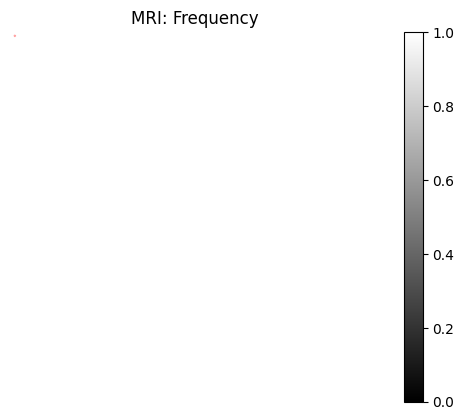

In [23]:
# draw circle
img_show = np.log(1 + np.abs(F_img_noise))
img_circle = drawCircle(img_show, 10, 10, 2, 1)

# show the image
plt.imshow(img_circle, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.axis('off')
plt.show()

问题：没有归一化

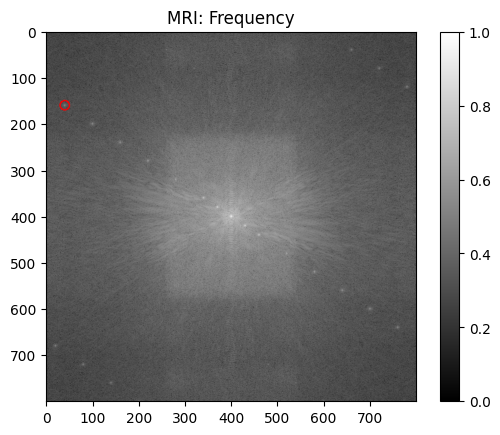

In [24]:
# draw circle
img_show = np.log(1 + np.abs(F_img_noise))
img_show_norm = (img_show - img_show.min()) / (img_show.max() - img_show.min())
img_circle = drawCircle(img_show_norm, 40, 160, 10, 2)
# img_circle = drawCircle(img_show_norm, 100, 200, 10, 2)
# img_circle = drawCircle(img_show_norm, 160, 240, 10, 2)

# show the image
plt.imshow(img_circle, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.show()

发现不能画多个圈，要优化画圈函数。

In [25]:
def drawCircle(img: np.ndarray, x: int, y: int, r: int, w: int):
    # color
    color = (1.0, 0, 0) if img.dtype.kind == 'f' else (255, 0, 0)
    # img_rgb
    if img.ndim == 2:
        img_rgb = img_rgb = np.stack([img, img, img], axis=-1)
    else:
        img_rgb = img.copy()
    return cv2.circle(img_rgb, (x, y), r, color, w)

(x, y):  [(40, 160), (100, 200), (160, 240), (220, 280), (280, 320), (340, 360), (400, 400), (460, 440), (520, 480), (580, 520), (640, 560), (700, 600), (760, 640)]
(x, y):  [(660, 40), (720, 80), (780, 120)]
(x, y):  [(20, 680), (80, 720), (140, 760)]
(x, y):  [(40, 160), (100, 200), (160, 240), (220, 280), (280, 320), (340, 360), (460, 440), (520, 480), (580, 520), (640, 560), (700, 600), (760, 640), (660, 40), (720, 80), (780, 120), (20, 680), (80, 720), (140, 760), (370, 380), (430, 420)]


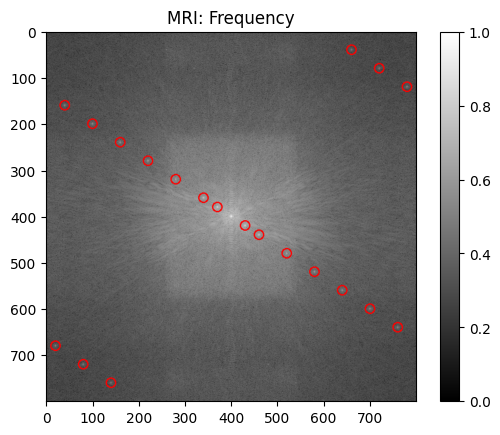

In [26]:
# draw circle
img_show = np.log(1 + np.abs(F_img_noise))
img_show_norm = (img_show - img_show.min()) / (img_show.max() - img_show.min())

# img_circle = drawCircle(img_circle, 660, 40, 10, 2)
# img_circle = drawCircle(img_circle, 20, 680, 10, 2)
xy_list = [(i, (i + 200) // 3 * 2) for i in range(40, 800, 60)]
print("(x, y): ", xy_list)
xy_up_list = [(i, i // 3 * 2 - 400) for i in range(660, 800, 60)]
print("(x, y): ", xy_up_list)
xy_down_list = [(j // 2 * 3 - 1000, j) for j in range(680, 800, 40)]
print("(x, y): ", xy_down_list)
xy_list = xy_list + xy_up_list + xy_down_list
xy_list.append((370, 380))
xy_list.append((430, 420))
xy_list.remove((400, 400))
print("(x, y): ", xy_list)
img_circle = img_show_norm
for i in range(len(xy_list)):
    img_circle = drawCircle(img_circle, int(xy_list[i][0]), int(xy_list[i][1]), 10, 2)


# show the image
plt.imshow(img_circle, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.show()

所有的坐标都放在 xy_list 中了。

In [27]:
def generateNotchFilter(img: np.ndarray, v0: int, u0: int, D0_notch: int):
    height, width = img.shape
    u = np.arange(height)
    v = np.arange(width)
    V, U = np.meshgrid(v, u)

    n_notch = 4
    D_k1 = np.sqrt((U - u0)**2 + (V - v0)**2)
    D_k2 = np.sqrt((U + u0)**2 + (V + v0)**2)
    D_k1[D_k1 == 0] = 1e-5
    D_k2[D_k2 == 0] = 1e-5

    H_notch = (1.0 / (1.0 + (D0_notch / D_k1)**(2 * n_notch))) * \
          (1.0 / (1.0 + (D0_notch / D_k2)**(2 * n_notch)))
    
    return H_notch

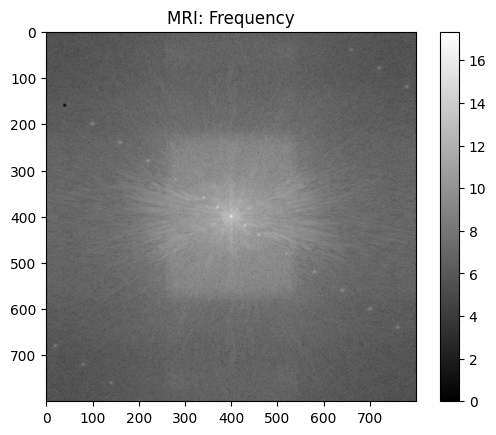

In [28]:
# original noise image
F_img_noise = np.fft.fftshift(np.fft.fft2(img_noise))
F_img_show = np.log(1 + np.abs(F_img_noise))
F_img_noise_norm = (F_img_show - F_img_show.min()) / (F_img_show.max() - F_img_show.min())

D0 = 5
H_notch_1 = generateNotchFilter(F_img_noise_norm, 40, 160, D0)
G = F_img_noise * H_notch_1
G_show = np.log(1 + np.abs(G))

# show the image
plt.imshow(G_show, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.show()


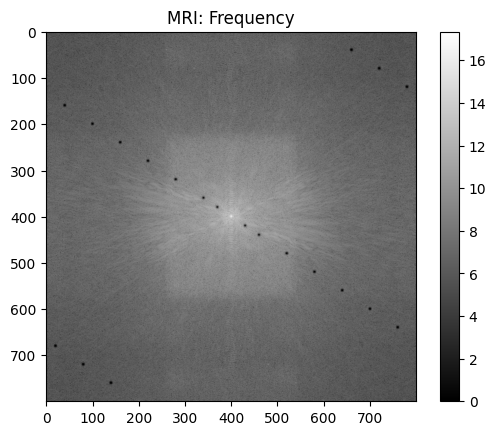

In [29]:
# original noise image
F_img_noise = np.fft.fftshift(np.fft.fft2(img_noise))
F_img_show = np.log(1 + np.abs(F_img_noise))
F_img_noise_norm = (F_img_show - F_img_show.min()) / (F_img_show.max() - F_img_show.min())

D0 = 5
G = F_img_noise
for i in range(len(xy_list)):
    H_notch = generateNotchFilter(F_img_noise_norm, xy_list[i][0], xy_list[i][1], D0)
    G = G * H_notch

G_show = np.log(1 + np.abs(G))

# show the image
plt.imshow(G_show, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.show()


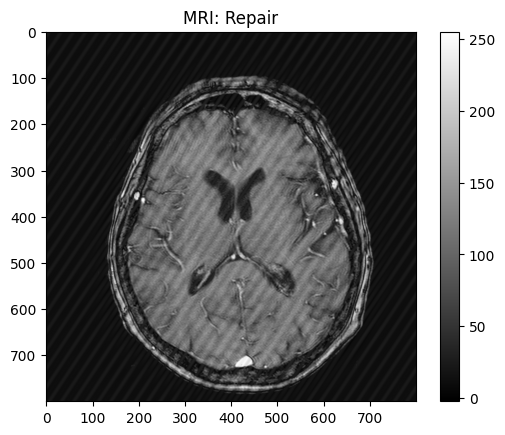

In [30]:
# original noise image
F_img_noise = np.fft.fftshift(np.fft.fft2(img_noise))
F_img_show = np.log(1 + np.abs(F_img_noise))
F_img_noise_norm = (F_img_show - F_img_show.min()) / (F_img_show.max() - F_img_show.min())

D0 = 5
g = img_noise
for i in range(len(xy_list)):
    H_notch = generateNotchFilter(F_img_noise_norm, xy_list[i][0], xy_list[i][1], D0)
    g = applyFrequencyFilter(g, H_notch)

# show the image
plt.imshow(g, cmap='gray')
plt.colorbar()
plt.title("MRI: Repair")
plt.show()


陷波最小值太小了，要优化一下。

In [31]:
def generateNotchFilter(img: np.ndarray, v0: int, u0: int, D0_notch: int, min: float):
    height, width = img.shape
    u = np.arange(height)
    v = np.arange(width)
    V, U = np.meshgrid(v, u)

    n_notch = 4
    D_k1 = np.sqrt((U - u0)**2 + (V - v0)**2)
    D_k2 = np.sqrt((U + u0)**2 + (V + v0)**2)
    D_k1[D_k1 == 0] = 1e-5
    D_k2[D_k2 == 0] = 1e-5

    H_notch = (1.0 / (1.0 + (D0_notch / D_k1)**(2 * n_notch))) * \
          (1.0 / (1.0 + (D0_notch / D_k2)**(2 * n_notch)))
    
    return min + (1.0 - min) * H_notch

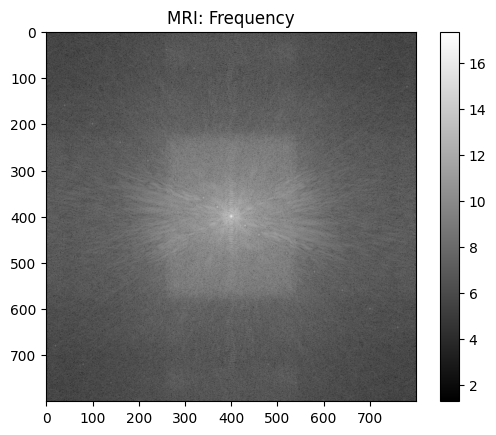

In [32]:
# original noise image
F_img_noise = np.fft.fftshift(np.fft.fft2(img_noise))
F_img_show = np.log(1 + np.abs(F_img_noise))
F_img_noise_norm = (F_img_show - F_img_show.min()) / (F_img_show.max() - F_img_show.min())

D0 = 5
min = 0.3
G = F_img_noise
for i in range(len(xy_list)):
    H_notch = generateNotchFilter(F_img_noise_norm, xy_list[i][0], xy_list[i][1], D0, min)
    G = G * H_notch

G_show = np.log(1 + np.abs(G))

# show the image
plt.imshow(G_show, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.show()


频率域的图像看起来好了很多。

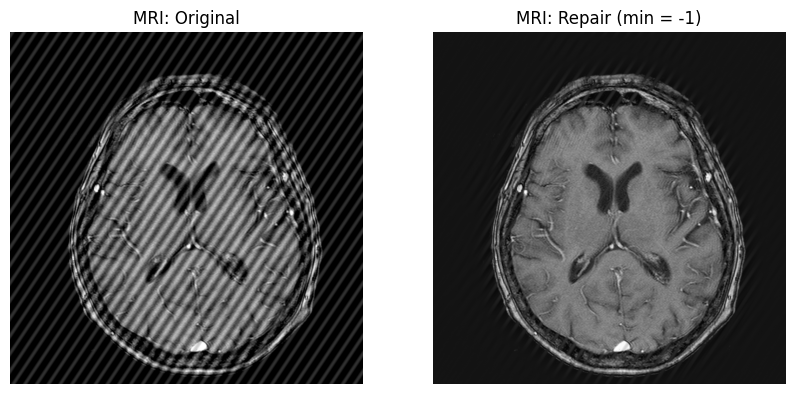

In [33]:
# original noise image
F_img_noise = np.fft.fftshift(np.fft.fft2(img_noise))
F_img_show = np.log(1 + np.abs(F_img_noise))
F_img_noise_norm = (F_img_show - F_img_show.min()) / (F_img_show.max() - F_img_show.min())

D0 = 5
min = -1
g = img_noise
for i in range(len(xy_list)):
    H_notch = generateNotchFilter(F_img_noise_norm, xy_list[i][0], xy_list[i][1], D0, min)
    g = applyFrequencyFilter(g, H_notch)

# show the image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[1].imshow(g, cmap='gray')
ax[1].set_title(f"MRI: Repair (min = {min})")
ax[0].imshow(img_noise, cmap='gray')
ax[0].set_title("MRI: Original")
for a in ax:
    a.axis("off")
plt.show()


尝试了很多参数 `min` 的取值，发现取负数的时候反而效果好了起来。

下面测试新的 notch filter，并将处理结果与原图直接对比。

In [34]:
def generateSoftGaussianNotchFilter(img: np.ndarray, v0: int, u0: int, sigma: float, alpha: float = 1.0):
    height, width = img.shape
    u = np.arange(height)
    v = np.arange(width)
    V, U = np.meshgrid(v, u)

    D_k1_sq = (U - u0) ** 2 + (V - v0) ** 2
    D_k2_sq = (U + u0) ** 2 + (V + v0) ** 2

    notch_1 = np.exp(-D_k1_sq / (2 * sigma ** 2))
    notch_2 = np.exp(-D_k2_sq / (2 * sigma ** 2))

    H = (1.0 - alpha * notch_1) * (1.0 - alpha * notch_2)
    return np.clip(H, 0.0, 1.0)


def applyCombinedSoftNotchFilter(img: np.ndarray, notch_points: list[tuple[int, int]], sigma: float = 5.0, alpha: float = 1.0):
    F = np.fft.fftshift(np.fft.fft2(img))
    H_total = np.ones(img.shape, dtype=np.float64)

    for v0, u0 in notch_points:
        H_total *= generateSoftGaussianNotchFilter(img, v0, u0, sigma=sigma, alpha=alpha)

    G = F * H_total
    g = np.fft.ifft2(np.fft.ifftshift(G)).real
    return g, H_total, F, G


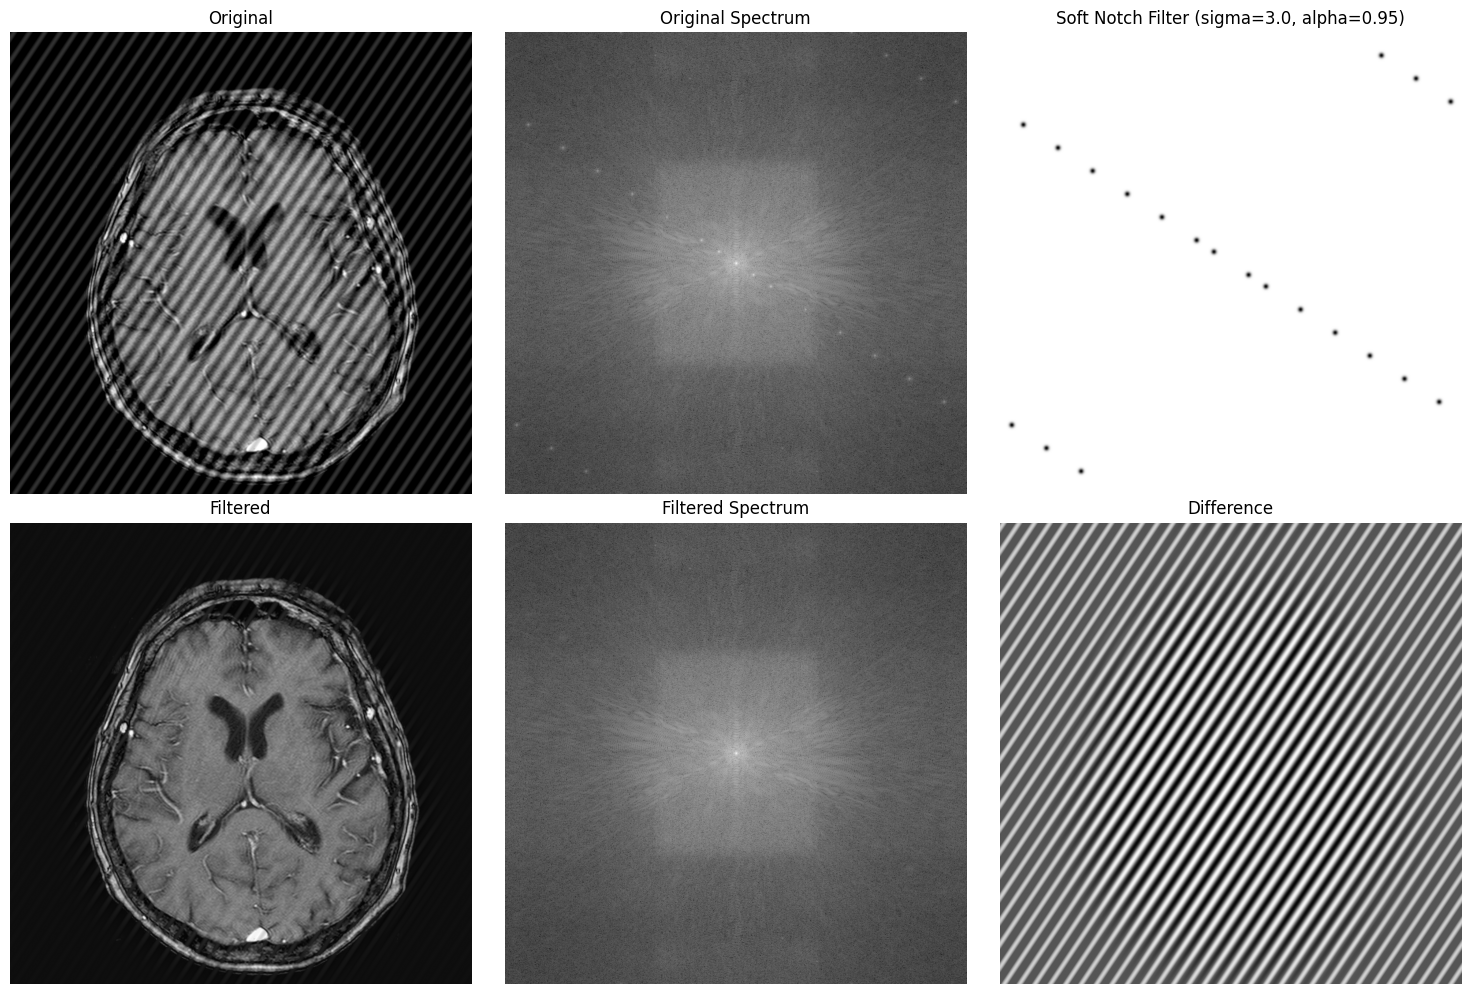

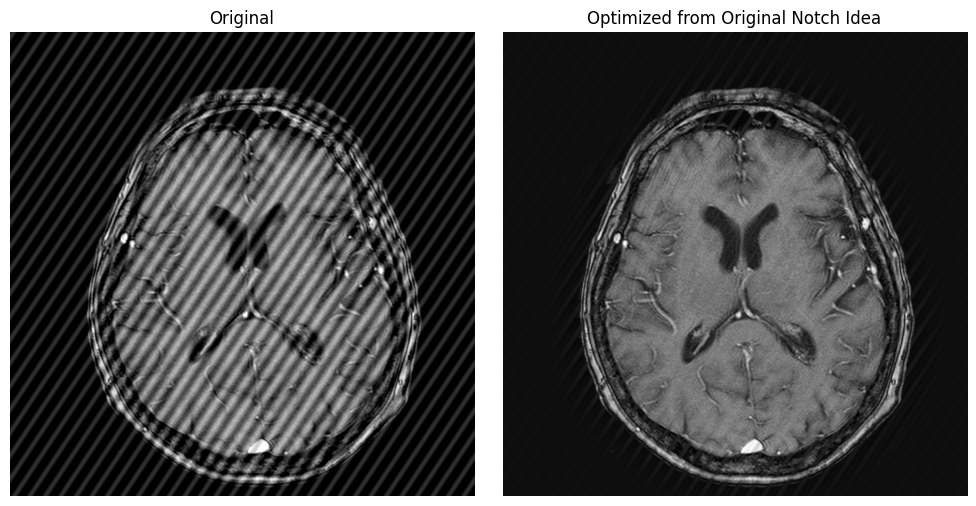

In [35]:
# optimize the original idea: keep the same coordinates, but use a smoother notch and apply it once in frequency domain
sigma_new = 3.0
alpha_new = 0.95

img_repair_soft, H_soft, F_soft_original, F_soft_filtered = applyCombinedSoftNotchFilter(
    img_noise,
    xy_list,
    sigma=sigma_new,
    alpha=alpha_new,
)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(img_noise, cmap='gray')
ax[0, 0].set_title('Original')
ax[0, 1].imshow(np.log(1 + np.abs(F_soft_original)), cmap='gray')
ax[0, 1].set_title('Original Spectrum')
ax[0, 2].imshow(H_soft, cmap='gray')
ax[0, 2].set_title(f'Soft Notch Filter (sigma={sigma_new}, alpha={alpha_new})')

ax[1, 0].imshow(img_repair_soft, cmap='gray')
ax[1, 0].set_title('Filtered')
ax[1, 1].imshow(np.log(1 + np.abs(F_soft_filtered)), cmap='gray')
ax[1, 1].set_title('Filtered Spectrum')
ax[1, 2].imshow(img_noise - img_repair_soft, cmap='gray')
ax[1, 2].set_title('Difference')

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_noise, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(img_repair_soft, cmap='gray')
ax[1].set_title('Optimized from Original Notch Idea')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


还是修改 notch 算法效果比较好。 